In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.font_manager as font_manager
from adjustText import adjust_text

font_dir = Path("/Users/sophiazhang/anaconda3/envs/shuoz/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf")
font_paths = [
    font_dir / "Myriad Pro Regular.ttf",
    font_dir / "Myriad Pro Bold.ttf",
    font_dir / "MYRIADPRO-SEMIBOLD.OTF"
]

for path in font_paths:
    font_manager.fontManager.addfont(str(path))

plt.rcParams["font.family"] = "Myriad Pro"

fs=16
fss=14
# ============================================================
# Supplementary analysis:
# 1. DP-to-hub transmission matrix
# 2. Leontief propagation-depth decomposition
# 3. Annual time-series decomposition
# ============================================================

In [4]:
file_path = Path("./digital_SUTs_IOTs/data_for_cal/Digital IO Tables 2000-2020 for China.xlsx")
main_yearly_fp = Path("./results/digital_consumption_metrics_2000_2020.csv")
main_sector_fp = Path("./results/sector_level_digital_metrics_2000_2020.csv")
out_dir = Path("./results/transmission_mechanism")
fig_dir = out_dir / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

years = [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,

         2008, 2009, 2010, 2011, 2012, 2013, 2014, 2017, 2018, 2020]
N = 94
row0 = 1
col0 = 1
rows = slice(row0, row0 + N)
cols = slice(col0, col0 + N)
col_C = col0 + N
row_VA = row0 + N
row_X  = row0 + N + 1

group = np.array(["NDP"] * 40 + ["DCP"] * 40 + ["DP"] * 14)
SECTOR_NAMES = [
    # 1–40 NDP
    "Agriculture", "Forestry", "Fishery", "Mining", "Food", "Textiles",
    "Paper", "Wood", "Petroleum", "Chemicals", "Pharma", "Rubber",
    "Nonmetal", "BasicMetals", "FabMetals", "Machinery", "Vehicles", "TransportEquip",
    "Electrical", "Instruments", "OtherMfg", "Electricity", "Water", "Construction",
    "WholesaleRetail", "WaterTrans", "AirTrans", "LandTrans", "Post", "Hospitality",
    "Finance", "RealEstate", "BusinessSvc", "R&D", "TechSvc", "HouseholdSvc",
    "Education", "Health", "Culture", "PublicAdmin",
    # 41–80 DCP
    "D-Agriculture", "D-Forestry", "D-Fishery", "D-Mining", "D-Food", "D-Textiles",
    "D-Paper", "D-Wood", "D-Petroleum", "D-Chemicals", "D-Pharma", "D-Rubber",
    "D-Nonmetal", "D-BasicMetals", "D-FabMetals", "D-Machinery", "D-Vehicles", "D-TransportEquip",
    "D-Electrical", "D-Instruments", "D-OtherMfg", "D-Electricity", "D-Water", "D-Construction",
    "D-WholesaleRetail", "D-WaterTrans", "D-AirTrans", "D-LandTrans", "D-Post", "D-Hospitality",
    "D-Finance", "D-RealEstate", "D-BusinessSvc", "D-R&D", "D-TechSvc", "D-HouseholdSvc",
    "D-Education", "D-Health", "D-Culture", "D-PublicAdmin",
    # 81–94 DP
    "DP-Media", "DP-Infochem", "DP-IntEquip", "DP-Opto", "DP-ICT", "DP-Infra",
    "DP-Ecommerce", "DP-Telecom", "DP-ITservices", "DP-Fintech", "DP-BizOnline",
    "DP-DigiR&D", "DP-3Dprint", "DP-ICTrepair"
]
dp_indices = list(range(80, 94))
non_dp_indices = list(range(0, 80))
dp_mask = np.zeros(N, dtype=bool)
dp_mask[dp_indices] = True
non_dp_mask = ~dp_mask

# Maximum explicitly calculated order for propagation-depth decomposition
# Order 1 = direct linkage
# Order 2 = two-step linkage
# Order 3 = three-step linkage
# Order 4+ = residual higher-order linkage
max_order = 3

In [5]:
def read_io_table(year):
    """Read Z, C, v, x from one year sheet."""
    df = pd.read_excel(file_path, sheet_name=str(year), header=None)
    Z = df.iloc[rows, cols].to_numpy(dtype=float)
    C = df.iloc[rows, col_C].to_numpy(dtype=float)
    v = df.iloc[row_VA, cols].to_numpy(dtype=float)
    x = df.iloc[row_X, cols].to_numpy(dtype=float)
    return Z, C, v, x

def compute_basic_objects(Z, C, v, x):
    """Compute A, L, value-added coefficients and baseline results."""
    x_safe = np.where(x == 0, 1e-9, x)
    A = Z / x_safe
    I = np.eye(N)
    L = np.linalg.inv(I - A)
    k = v / x_safe
    x_c_base = L @ C
    total_va_base = float(np.dot(k, x_c_base))
    sector_va_base = k * x_c_base
    return A, L, k, x_c_base, total_va_base, sector_va_base

def remove_rows_from_A(A, row_indices):
    """Set selected supplying-sector rows of A to zero."""
    A_new = A.copy()
    A_new[row_indices, :] = 0.0
    return A_new

def interpolate_years(df, year_col="year"):
    """Interpolate missing years for visualization only."""
    df = df.copy()
    df = df.sort_values(year_col)
    df[year_col] = df[year_col].astype(int)
    df = df.set_index(year_col)
    full_years = np.arange(df.index.min(), df.index.max() + 1)
    df = df.reindex(full_years)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].interpolate(method="linear", limit_direction="both")
    df = df.reset_index().rename(columns={"index": year_col})
    return df

In [6]:
df_main_yearly = pd.read_csv(main_yearly_fp).sort_values("year")
df_main_sector = pd.read_csv(main_sector_fp).sort_values(["year", "sector_index"])
# Standardize column names for easier use in this script
# Main code columns:
# - DP_Support
# - DP_FinalDemand
# - DP_TotalEffect
# - DP_Support_t_i
# - DP_FinalDemand_t_i
# - DP_TotalEffect_t_i
df_main_yearly["SupportShare"] = (
    df_main_yearly["DP_Support"] / df_main_yearly["DP_TotalEffect"]
)

In [7]:
dp_to_hub_rows = []
propagation_rows = []
propagation_sector_rows = []

for yr in years:
    print(f"Processing supplementary mechanism analysis for year {yr}...")
    Z, C, v, x = read_io_table(yr)
    A, L, k, x_c_base, total_va_base, sector_va_base = compute_basic_objects(Z, C, v, x)
    I = np.eye(N)
    # ------------------------------------------------------------
    # Retrieve all-DP sectoral support effects from main output
    # ------------------------------------------------------------
    df_sector_yr = df_main_sector[df_main_sector["year"] == yr].copy()
    # Ensure correct sector order
    df_sector_yr = df_sector_yr.sort_values("sector_index")
    DP_Support_sector = df_sector_yr["DP_Support_t_i"].to_numpy(dtype=float)
    DP_Support_total = float(df_main_yearly.loc[df_main_yearly["year"] == yr, "DP_Support"].iloc[0])
    # ------------------------------------------------------------
    # Construct all-DP removal matrix only for propagation-depth decomposition
    A_noDP = remove_rows_from_A(A, dp_indices)
    # ============================================================
    # 3.1 DP -> hub transmission matrix
    # Single-DP hypothetical extraction:
    # remove one DP provider at a time and compute its marginal
    # support effect on each non-DP hub sector.
    for p in dp_indices:
        A_no_p = remove_rows_from_A(A, [p])
        L_no_p = np.linalg.inv(I - A_no_p)
        x_c_no_p = L_no_p @ C # total output embodied in household consumption with one DP removed
        sector_va_no_p = k * x_c_no_p # sectoral value-added embodied in household consumption with one DP removed
        support_p_to_i = sector_va_base - sector_va_no_p # marginal support effect of DP p on each sector i
        for i in non_dp_indices:
            dp_to_hub_rows.append({
                "year": yr,
                "dp_provider_index": p, # index of the DP provider removed
                "dp_provider": SECTOR_NAMES[p], # name of the DP provider removed
                "hub_sector_index": i, # index of the non-DP hub sector affected
                "hub_sector": SECTOR_NAMES[i], # name of the non-DP hub sector affected
                "hub_group": group[i], # group of the non-DP hub sector affected
                "support_from_dp_to_hub": float(support_p_to_i[i]), # marginal support from DP p to hub sector i
                "all_DP_support_of_hub": float(DP_Support_sector[i]), # total support from all DPs to hub sector i
                "share_in_hub_all_DP_support": (
                    float(support_p_to_i[i] / DP_Support_sector[i]) # share of DP p's support in total DP support to hub sector i
                    if DP_Support_sector[i] != 0 else np.nan 
                )
            })
    # ============================================================
    # 3.2 Leontief propagation-depth decomposition
    #
    # L - L_noDP = (A - A_noDP)
    #             + (A^2 - A_noDP^2)
    #             + (A^3 - A_noDP^3)
    #             + higher-order residual
    # ============================================================
    A_power = np.eye(N) # initialize A^0 as identity for iterative computation
    A_noDP_power = np.eye(N)
    accumulated_sector_support = np.zeros(N)
    for order in range(1, max_order + 1):
        A_power = A_power @ A # compute A^order iteratively
        A_noDP_power = A_noDP_power @ A_noDP # compute A_noDP^order iteratively
        delta_x_order = (A_power - A_noDP_power) @ C # change in household-consumption-embodied output at this order due to all-DP removal
        va_order_sector = k * delta_x_order # sectoral value-added change at this order due to all-DP removal
        va_order_total = float(va_order_sector.sum()) # total value-added change at this order due to all-DP removal
        accumulated_sector_support += va_order_sector # accumulate sectoral support up to this order for later use in residual calculation
        propagation_rows.append({
            "year": yr,
            "order": order, # propagation layer order
            "layer": f"Order {order}", # propagation layer label
            "DP_support_by_layer": va_order_total, # DP support by propagation layer
            "share_in_total_support": (
                va_order_total / DP_Support_total # share of this layer's support in total DP support
                if DP_Support_total != 0 else np.nan
            )
        }) # DP support by propagation layer for total DP support
        for i in range(N):
            propagation_sector_rows.append({
                "year": yr,
                "order": order,
                "layer": f"Order {order}",
                "sector_index": i, # index of the sector
                "sector_name": SECTOR_NAMES[i], # name of the sector
                "group": group[i], # group of the sector
                "DP_support_by_layer_sector": float(va_order_sector[i]), # DP support by propagation layer for each sector
                "total_DP_support_sector": float(DP_Support_sector[i]), # total DP support for each sector from main results for comparison
                "share_in_sector_support": (
                    float(va_order_sector[i] / DP_Support_sector[i]) # share of this layer's support in total DP support for each sector
                    if DP_Support_sector[i] != 0 else np.nan
                )
            }) # DP support by propagation layer for each sector

    # Residual higher-order effect: Order 4+
    residual_sector = DP_Support_sector - accumulated_sector_support # residual support not explained by orders 1 to max_order
    residual_total = float(residual_sector.sum()) # total residual support not explained by orders 1 to max_order
    propagation_rows.append({
        "year": yr,
        "order": max_order + 1,# order for residual layer
        "layer": f"Order {max_order + 1}+",
        "DP_support_by_layer": residual_total,# DP support by residual higher-order propagation layer
        "share_in_total_support": (
            residual_total / DP_Support_total
            if DP_Support_total != 0 else np.nan
        )
    }) # residual higher-order support for total DP support

    for i in range(N):
        propagation_sector_rows.append({
            "year": yr,
            "order": max_order + 1,
            "layer": f"Order {max_order + 1}+",
            "sector_index": i,
            "sector_name": SECTOR_NAMES[i],
            "group": group[i],
            "DP_support_by_layer_sector": float(residual_sector[i]),
            "total_DP_support_sector": float(DP_Support_sector[i]), # total DP support for each sector from main results for comparison
            "share_in_sector_support": (
                float(residual_sector[i] / DP_Support_sector[i])
                if DP_Support_sector[i] != 0 else np.nan
            )
        }) # residual higher-order support by sector

Processing supplementary mechanism analysis for year 2000...
Processing supplementary mechanism analysis for year 2001...
Processing supplementary mechanism analysis for year 2002...
Processing supplementary mechanism analysis for year 2003...
Processing supplementary mechanism analysis for year 2004...
Processing supplementary mechanism analysis for year 2005...
Processing supplementary mechanism analysis for year 2006...
Processing supplementary mechanism analysis for year 2007...
Processing supplementary mechanism analysis for year 2008...
Processing supplementary mechanism analysis for year 2009...
Processing supplementary mechanism analysis for year 2010...
Processing supplementary mechanism analysis for year 2011...
Processing supplementary mechanism analysis for year 2012...
Processing supplementary mechanism analysis for year 2013...
Processing supplementary mechanism analysis for year 2014...
Processing supplementary mechanism analysis for year 2017...
Processing supplementary

In [8]:
df_dp_to_hub = pd.DataFrame(dp_to_hub_rows).sort_values(
    ["year", "hub_sector", "support_from_dp_to_hub"],
    ascending=[True, True, False]) 
df_propagation = pd.DataFrame(propagation_rows).sort_values(["year", "order"])
df_propagation_sector = pd.DataFrame(propagation_sector_rows).sort_values(
    ["year", "sector_index", "order"])
df_dp_to_hub.to_csv(
    out_dir / "dp_to_hub_transmission_matrix_all_years.csv",
    index=False)
df_propagation.to_csv(
    out_dir / "leontief_propagation_depth_decomposition.csv",
    index=False)
df_propagation_sector.to_csv(
    out_dir / "leontief_propagation_depth_sector.csv",
    index=False)

print("Saved new supplementary outputs:")
print(out_dir / "dp_to_hub_transmission_matrix_all_years.csv")
print(out_dir / "leontief_propagation_depth_decomposition.csv")
print(out_dir / "leontief_propagation_depth_sector.csv")

Saved new supplementary outputs:
results/transmission_mechanism/dp_to_hub_transmission_matrix_all_years.csv
results/transmission_mechanism/leontief_propagation_depth_decomposition.csv
results/transmission_mechanism/leontief_propagation_depth_sector.csv


In [26]:
# Sanity check: the sum of DP support across all layers should equal total DP support in main results for each year
check = df_propagation.pivot_table(
    index="year",
    columns="layer",
    values="share_in_total_support",
    aggfunc="sum"
)
check["sum_share"] = check.sum(axis=1) # this should be 1 for all years if the decomposition is correct
print(check[["sum_share"]])

layer  sum_share
year            
2000         1.0
2001         1.0
2002         1.0
2003         1.0
2004         1.0
2005         1.0
2006         1.0
2007         1.0
2008         1.0
2009         1.0
2010         1.0
2011         1.0
2012         1.0
2013         1.0
2014         1.0
2017         1.0
2018         1.0
2020         1.0


Processing DP-to-hub transmission matrix for 2000...
Saved overall top DP-to-hub transmission pathway table:
results/transmission_mechanism/table_overall_top_DP_to_hub_pathways_2000.csv
Saved heatmap:
results/transmission_mechanism/figures/fig_DP_to_hub_transmission_matrix_2000.png


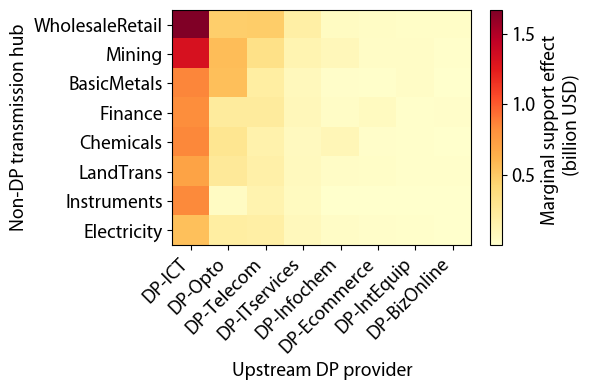

Processing DP-to-hub transmission matrix for 2008...
Saved overall top DP-to-hub transmission pathway table:
results/transmission_mechanism/table_overall_top_DP_to_hub_pathways_2008.csv
Saved heatmap:
results/transmission_mechanism/figures/fig_DP_to_hub_transmission_matrix_2008.png


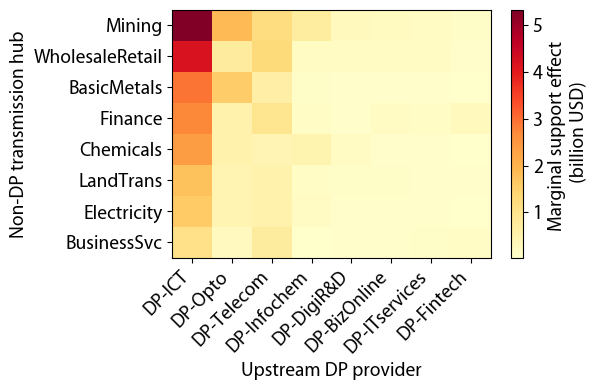

Processing DP-to-hub transmission matrix for 2013...
Saved overall top DP-to-hub transmission pathway table:
results/transmission_mechanism/table_overall_top_DP_to_hub_pathways_2013.csv
Saved heatmap:
results/transmission_mechanism/figures/fig_DP_to_hub_transmission_matrix_2013.png


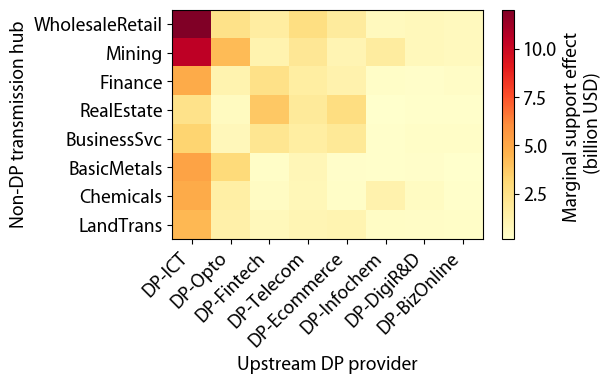

Processing DP-to-hub transmission matrix for 2020...
Saved overall top DP-to-hub transmission pathway table:
results/transmission_mechanism/table_overall_top_DP_to_hub_pathways_2020.csv
Saved heatmap:
results/transmission_mechanism/figures/fig_DP_to_hub_transmission_matrix_2020.png


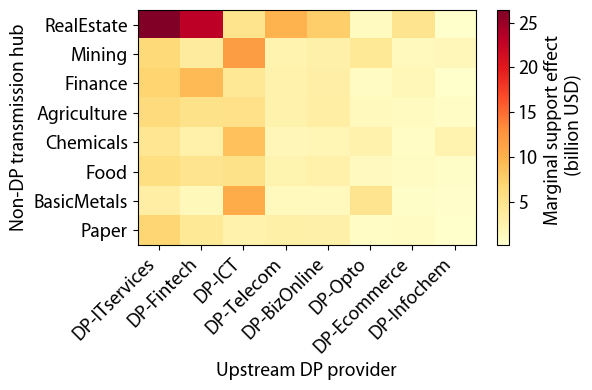

In [36]:
# ============================================================
# DP-to-hub transmission matrix heatmaps for selected years
# Each year selects its own top hubs and top DP providers
# ============================================================
selected_years = [2000, 2008, 2013, 2020]
top_hub_n = 8
top_provider_n = 8
overall_top_n = 20   # compact SI table: overall top pathways for each year

for target_year in selected_years:

    print(f"Processing DP-to-hub transmission matrix for {target_year}...")

    # ------------------------------------------------------------
    # Select top non-DP hubs for this year
    # ------------------------------------------------------------
    df_sector_y = df_main_sector[
        (df_main_sector["year"] == target_year) &
        (df_main_sector["group"] != "DP")
    ].copy()

    top_hubs = (
        df_sector_y
        .sort_values("DP_Support_t_i", ascending=False)
        .head(top_hub_n)["sector_name"]
        .tolist()
    )

    # Data for heatmap: only top hubs in this year
    df_trans_y = df_dp_to_hub[
        (df_dp_to_hub["year"] == target_year) &
        (df_dp_to_hub["hub_sector"].isin(top_hubs))
    ].copy()

    # ------------------------------------------------------------
    # Compact SI table:
    # Overall top DP-to-hub transmission pathways for this year
    # ------------------------------------------------------------
    df_trans_y_all = df_dp_to_hub[
        df_dp_to_hub["year"] == target_year
    ].copy()

    # Keep only positive transmission effects
    df_trans_y_all = df_trans_y_all[
        df_trans_y_all["support_from_dp_to_hub"] > 0
    ].copy()

    df_top_pathways_overall = (
        df_trans_y_all
        .sort_values("support_from_dp_to_hub", ascending=False)
        .head(overall_top_n)
        .copy()
    )

    df_top_pathways_overall.insert(
        1,
        "overall_rank",
        np.arange(1, len(df_top_pathways_overall) + 1)
    )

    df_top_pathways_overall["support_from_dp_to_hub_billion"] = (
        df_top_pathways_overall["support_from_dp_to_hub"] / 1e3
    )

    df_top_pathways_overall = df_top_pathways_overall[
        [
            "year",
            "overall_rank",
            "dp_provider",
            "hub_sector",
            "support_from_dp_to_hub",
            "support_from_dp_to_hub_billion",
            "all_DP_support_of_hub",
            "share_in_hub_all_DP_support"
        ]
    ]
    out_table = out_dir / f"table_overall_top_DP_to_hub_pathways_{target_year}.csv"
    df_top_pathways_overall.to_csv(out_table, index=False)
    print("Saved overall top DP-to-hub transmission pathway table:")
    print(out_table)

    # ------------------------------------------------------------
    # Figure: DP-to-hub transmission matrix heatmap for this year
    # ------------------------------------------------------------
    top_providers = (
        df_trans_y
        .groupby("dp_provider")["support_from_dp_to_hub"]
        .sum()
        .sort_values(ascending=False)
        .head(top_provider_n)
        .index
        .tolist()
    )
    heat_mat = (
        df_trans_y[df_trans_y["dp_provider"].isin(top_providers)]
        .pivot_table(
            index="hub_sector",
            columns="dp_provider",
            values="support_from_dp_to_hub",
            aggfunc="sum"
        )
        .reindex(index=top_hubs, columns=top_providers)
        .fillna(0.0)
    )
    # Convert to billion USD; baseline unit is million USD
    heat_values = heat_mat.values / 1e3

    fig, ax = plt.subplots(figsize=(6, 4), facecolor="none")
    im = ax.imshow(
        heat_values,
        aspect="auto",
        cmap="YlOrRd"
    )
    ax.set_xticks(np.arange(len(top_providers)))
    ax.set_xticklabels(
        top_providers,
        rotation=45,
        ha="right",
        fontsize=fss
    )
    ax.set_yticks(np.arange(len(top_hubs)))
    ax.set_yticklabels(top_hubs, fontsize=fss)
    ax.set_xlabel("Upstream DP provider", fontsize=fss)
    ax.set_ylabel("Non-DP transmission hub", fontsize=fss)

    # # Add year label
    # ax.text(
    #     0.02,
    #     1.04,
    #     f"{target_year}",
    #     transform=ax.transAxes,
    #     ha="left",
    #     va="bottom",
    #     fontsize=fss + 2,
    #     fontweight="bold"
    # )

    ax.set_facecolor("none")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Marginal support effect \n (billion USD)", fontsize=fss)
    cbar.ax.tick_params(labelsize=fss)
    fig.tight_layout()
    out_fig = fig_dir / f"fig_DP_to_hub_transmission_matrix_{target_year}.png"
    fig.savefig(
        out_fig,
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )
    print("Saved heatmap:")
    print(out_fig)
    plt.show()

# plot

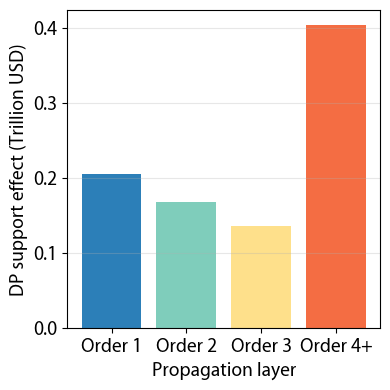

In [24]:
# ------------------------------------------------------------
# Figure:Leontief propagation-depth decomposition, 2020
# ------------------------------------------------------------
colors = {
    "Order 1": "#2C7FB8",
    "Order 2": "#7FCDBB",
    "Order 3": "#FEE08B",
    "Order 4+": "#F46D43"
}

df_prop_2020 = df_propagation[df_propagation["year"] == target_year].copy()
df_prop_2020 = df_prop_2020.sort_values("order")

bar_colors = [colors.get(layer, "gray") for layer in df_prop_2020["layer"]]
fig, ax = plt.subplots(figsize=(4, 4), facecolor="none")
ax.bar(
    df_prop_2020["layer"],
    df_prop_2020["DP_support_by_layer"] / 1e6,
    color=bar_colors,
    edgecolor="none"
)
ax.set_xlabel("Propagation layer", fontsize=fss)
ax.set_ylabel("DP support effect (Trillion USD)", fontsize=fss)
ax.tick_params(labelsize=fss)
ax.grid(axis="y", alpha=0.3)
ax.set_facecolor("none")
fig.tight_layout()
fig.savefig(
    fig_dir / "fig_leontief_propagation_depth_2020.png",
    dpi=300,
    transparent=True
)
plt.show()

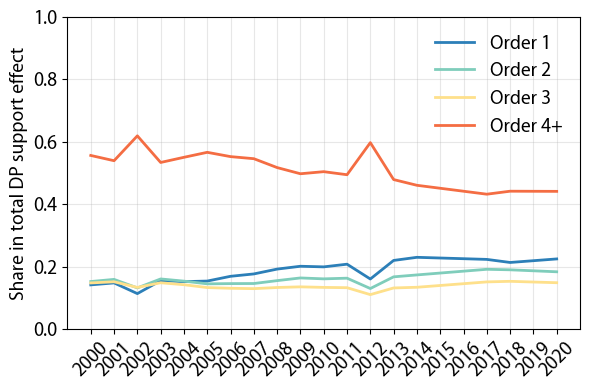

In [25]:
# ------------------------------------------------------------
# Figure: Propagation-depth shares over time
# ------------------------------------------------------------
prop_layers = []
for layer, g in df_propagation.groupby("layer"):
    g_interp = interpolate_years(
        g[["year", "DP_support_by_layer", "share_in_total_support"]]
    )
    g_interp["layer"] = layer
    prop_layers.append(g_interp)
df_prop_interp = pd.concat(prop_layers, ignore_index=True)
years = sorted(df_prop_interp["year"].astype(int).unique())
layer_order = ["Order 1", "Order 2", "Order 3", "Order 4+"]

fig, ax = plt.subplots(figsize=(6, 4), facecolor="none")
for layer in layer_order:
    if layer in df_prop_interp["layer"].unique():
        g = df_prop_interp[df_prop_interp["layer"] == layer].sort_values("year")
        ax.plot(
            g["year"],
            g["share_in_total_support"],
            linewidth=2,
            label=layer,
            color=colors[layer]
        )
ax.set_ylabel("Share in total DP support effect", fontsize=fss)
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=fss, rotation=45)
ax.tick_params(axis="y", labelsize=fss)
ax.set_ylim(0, 1)
ax.tick_params(labelsize=fss)
ax.legend(frameon=False, fontsize=fss)
ax.grid(alpha=0.3)
ax.set_facecolor("none")
fig.tight_layout()
fig.savefig(
    fig_dir / "fig_leontief_propagation_depth_shares_2000_2020.png",
    dpi=300,
    transparent=True
)
plt.show()